# AI News Credibility Analyzer

## Day 1: Data Collection, Data Cleaning and Exploratory Data Analysis (EDA)

### Objectives
- Import required libraries
- Load the Fake and Real News datasets
- Explore the dataset structure
- Merge both datasets
- Perform data cleaning and preprocessing
- Conduct Exploratory Data Analysis (EDA)
- Save the processed dataset for model training

### Expected Outcome
At the end of Day 1, we will have a clean and processed dataset ready for machine learning model training.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re
import string

from wordcloud import WordCloud

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download NLTK resources (only first time)
nltk.download('stopwords')
nltk.download('wordnet')

# Display settings
pd.set_option("display.max_columns", None)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [3]:
fake = pd.read_csv("../data/raw/Fake.csv")
true = pd.read_csv("../data/raw/True.csv")

print("Fake Dataset Shape :", fake.shape)
print("True Dataset Shape :", true.shape)

Fake Dataset Shape : (23481, 4)
True Dataset Shape : (21417, 4)


In [4]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [5]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [6]:
fake.info()

print("-"*50)

true.info()

<class 'pandas.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    23481 non-null  str  
 1   text     23481 non-null  str  
 2   subject  23481 non-null  str  
 3   date     23481 non-null  str  
dtypes: str(4)
memory usage: 60.4 MB
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    21417 non-null  str  
 1   text     21417 non-null  str  
 2   subject  21417 non-null  str  
 3   date     21417 non-null  str  
dtypes: str(4)
memory usage: 51.6 MB


In [7]:
fake["label"] = 0
true["label"] = 1

In [8]:
news = pd.concat([fake, true], ignore_index=True)

news = news.sample(frac=1, random_state=42).reset_index(drop=True)

news.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [9]:
news.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

In [10]:
news.dropna(inplace=True)
news.drop_duplicates(inplace=True)

print("Dataset Shape :", news.shape)

Dataset Shape : (44689, 5)


In [11]:
# Combine title and article text

news["content"] = news["title"] + " " + news["text"]

news[["title", "content"]].head()

,title,content
0,Ben Stein Calls Out 9th Circuit Court: Committ...,Ben Stein Calls Out 9th Circuit Court: Committ...
1,Trump drops Steve Bannon from National Securit...,Trump drops Steve Bannon from National Securit...
2,Puerto Rico expects U.S. to lift Jones Act shi...,Puerto Rico expects U.S. to lift Jones Act shi...
3,OOPS: Trump Just Accidentally Confirmed He Le...,OOPS: Trump Just Accidentally Confirmed He Le...
4,Donald Trump heads for Scotland to reopen a go...,Donald Trump heads for Scotland to reopen a go...


In [12]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"<.*?>", "", text)

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [13]:
news["clean_text"] = news["content"].apply(clean_text)

news[["content", "clean_text"]].head()

,content,clean_text
0,Ben Stein Calls Out 9th Circuit Court: Committ...,ben stein call th circuit court committed coup...
1,Trump drops Steve Bannon from National Securit...,trump drop steve bannon national security coun...
2,Puerto Rico expects U.S. to lift Jones Act shi...,puerto rico expects u lift jones act shipping ...
3,OOPS: Trump Just Accidentally Confirmed He Le...,oops trump accidentally confirmed leaked israe...
4,Donald Trump heads for Scotland to reopen a go...,donald trump head scotland reopen golf resort ...


In [14]:
news["word_count"] = news["clean_text"].apply(lambda x: len(x.split()))

news["char_count"] = news["clean_text"].apply(len)

news["sentence_count"] = news["content"].str.count(r"[.!?]") + 1

news.head()

,title,text,subject,date,label,content,clean_text,word_count,char_count,sentence_count
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0,Ben Stein Calls Out 9th Circuit Court: Committ...,ben stein call th circuit court committed coup...,109,791,7
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1,Trump drops Steve Bannon from National Securit...,trump drop steve bannon national security coun...,472,3540,45
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1,Puerto Rico expects U.S. to lift Jones Act shi...,puerto rico expects u lift jones act shipping ...,182,1310,23
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0,OOPS: Trump Just Accidentally Confirmed He Le...,oops trump accidentally confirmed leaked israe...,114,934,13
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1,Donald Trump heads for Scotland to reopen a go...,donald trump head scotland reopen golf resort ...,308,2250,32


In [15]:
print(news.shape)

news.info()

(44689, 10)
<class 'pandas.DataFrame'>
Index: 44689 entries, 0 to 44897
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   title           44689 non-null  str  
 1   text            44689 non-null  str  
 2   subject         44689 non-null  str  
 3   date            44689 non-null  str  
 4   label           44689 non-null  int64
 5   content         44689 non-null  str  
 6   clean_text      44689 non-null  str  
 7   word_count      44689 non-null  int64
 8   char_count      44689 non-null  int64
 9   sentence_count  44689 non-null  int64
dtypes: int64(4), str(6)
memory usage: 297.8 MB


C:\Users\HP\AppData\Local\Temp\ipykernel_21924\26516343.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


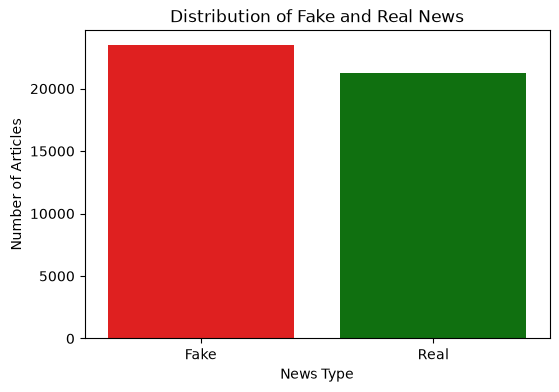

In [16]:
# Fake vs Real News Distribution

plt.figure(figsize=(6,4))

sns.countplot(
    x="label",
    data=news,
    palette=["red","green"]
)

plt.title("Distribution of Fake and Real News")

plt.xlabel("News Type")

plt.ylabel("Number of Articles")

plt.xticks([0,1],["Fake","Real"])

plt.show()


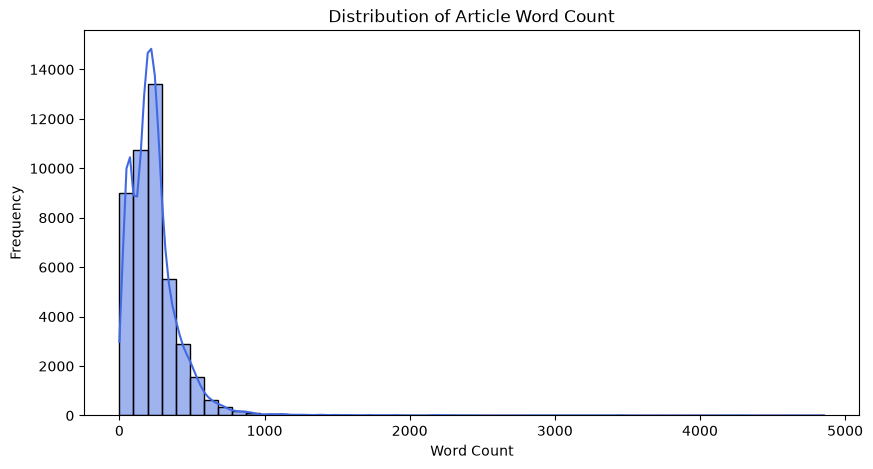

In [17]:
# Distribution of Word Count

plt.figure(figsize=(10,5))

sns.histplot(
    news["word_count"],
    bins=50,
    kde=True,
    color="royalblue"
)

plt.title("Distribution of Article Word Count")

plt.xlabel("Word Count")

plt.ylabel("Frequency")

plt.show()

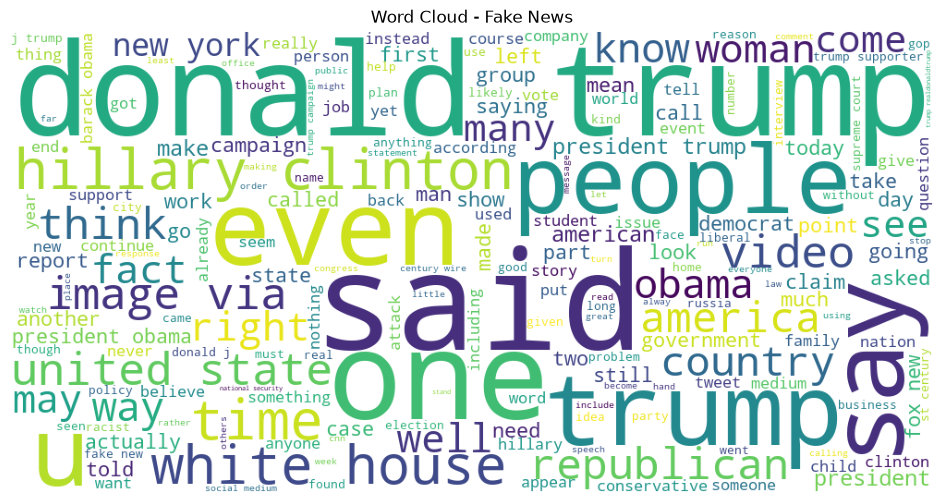

In [18]:
fake_words = " ".join(news[news["label"] == 0]["clean_text"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(fake_words)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Word Cloud - Fake News")

plt.show()

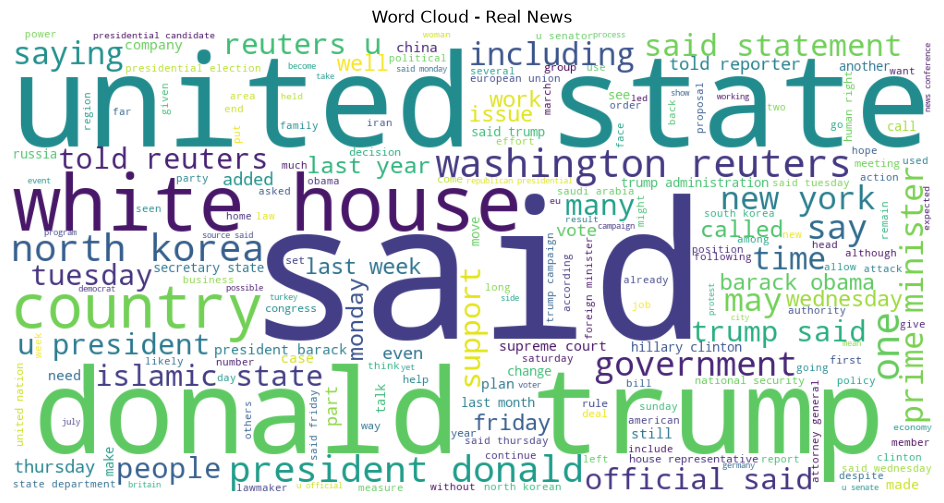

In [19]:
real_words = " ".join(news[news["label"] == 1]["clean_text"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(real_words)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Word Cloud - Real News")

plt.show()

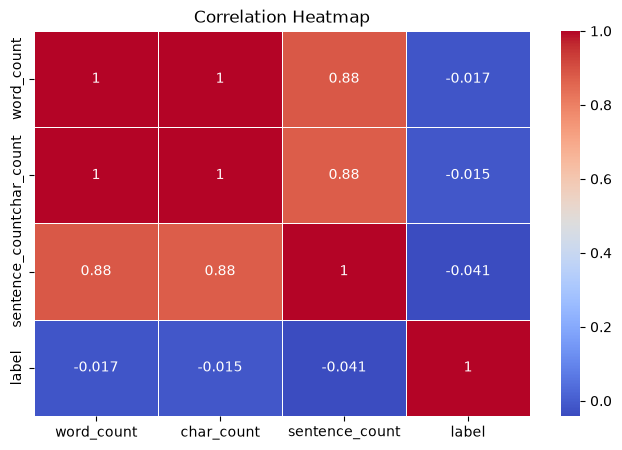

In [20]:
plt.figure(figsize=(8,5))

sns.heatmap(
    news[["word_count","char_count","sentence_count","label"]].corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_21924\2891725497.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


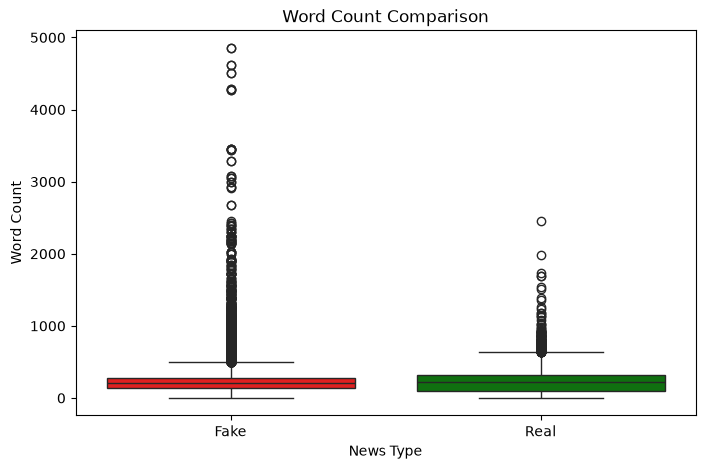

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="label",
    y="word_count",
    data=news,
    palette=["red","green"]
)

plt.xticks([0,1],["Fake","Real"])

plt.title("Word Count Comparison")

plt.xlabel("News Type")

plt.ylabel("Word Count")

plt.show()

In [22]:
news.to_csv(
    "../data/processed/processed_news.csv",
    index=False
)

print("Processed dataset saved successfully!")

Processed dataset saved successfully!


In [23]:
# Display the final processed dataset

news.head()

,title,text,subject,date,label,content,clean_text,word_count,char_count,sentence_count
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0,Ben Stein Calls Out 9th Circuit Court: Committ...,ben stein call th circuit court committed coup...,109,791,7
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1,Trump drops Steve Bannon from National Securit...,trump drop steve bannon national security coun...,472,3540,45
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1,Puerto Rico expects U.S. to lift Jones Act shi...,puerto rico expects u lift jones act shipping ...,182,1310,23
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0,OOPS: Trump Just Accidentally Confirmed He Le...,oops trump accidentally confirmed leaked israe...,114,934,13
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1,Donald Trump heads for Scotland to reopen a go...,donald trump head scotland reopen golf resort ...,308,2250,32


In [24]:
print("Final Dataset Shape :", news.shape)

news.columns


Final Dataset Shape : (44689, 10)


Index(['title', 'text', 'subject', 'date', 'label', 'content', 'clean_text',
       'word_count', 'char_count', 'sentence_count'],
      dtype='str')

In [25]:
news.to_csv("../data/processed/processed_news.csv", index=False)

# AI News Credibility Analyzer

## Day 2: Feature Engineering, Model Training and Performance Evaluation

### Objectives
- Load the processed dataset
- Convert text into numerical features using TF-IDF
- Split the dataset into training and testing sets
- Train multiple machine learning models
- Evaluate the models using Accuracy, Precision, Recall and F1 Score
- Compare model performance
- Save the trained models for deployment

### Expected Outcome
At the end of Day 2, we will have trained machine learning models capable of predicting fake and real news articles and evaluated them on unseen test data.

In [26]:
import pandas as pd
import numpy as np

import joblib
import json

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [27]:
news = pd.read_csv("../data/processed/processed_news.csv")

news.head()

,title,text,subject,date,label,content,clean_text,word_count,char_count,sentence_count
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0,Ben Stein Calls Out 9th Circuit Court: Committ...,ben stein call th circuit court committed coup...,109,791,7
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1,Trump drops Steve Bannon from National Securit...,trump drop steve bannon national security coun...,472,3540,45
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1,Puerto Rico expects U.S. to lift Jones Act shi...,puerto rico expects u lift jones act shipping ...,182,1310,23
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0,OOPS: Trump Just Accidentally Confirmed He Le...,oops trump accidentally confirmed leaked israe...,114,934,13
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1,Donald Trump heads for Scotland to reopen a go...,donald trump head scotland reopen golf resort ...,308,2250,32


In [28]:
X = news["clean_text"]

y = news["label"]

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples : 35751
Testing Samples : 8938


In [32]:
news["clean_text"].isna().sum()

np.int64(9)

In [33]:
# Remove rows with missing clean_text
news = news.dropna(subset=["clean_text"])

# Remove empty strings (if any)
news = news[news["clean_text"].str.strip() != ""]

# Reset index
news.reset_index(drop=True, inplace=True)

print("Dataset Shape:", news.shape)

# Verify no missing values remain
print("Missing values in clean_text:", news["clean_text"].isna().sum())

Dataset Shape: (44680, 10)
Missing values in clean_text: 0


In [34]:
X = news["clean_text"]
y = news["label"]

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples : 35744
Testing Samples : 8936


In [36]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)

(35744, 10000)


In [37]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_tfidf, y_train)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


In [38]:
logistic_prediction = logistic_model.predict(X_test_tfidf)

In [39]:
logistic_accuracy = accuracy_score(y_test, logistic_prediction)
logistic_precision = precision_score(y_test, logistic_prediction)
logistic_recall = recall_score(y_test, logistic_prediction)
logistic_f1 = f1_score(y_test, logistic_prediction)

print(f"Accuracy  : {logistic_accuracy:.4f}")
print(f"Precision : {logistic_precision:.4f}")
print(f"Recall    : {logistic_recall:.4f}")
print(f"F1 Score  : {logistic_f1:.4f}")

Accuracy  : 0.9906
Precision : 0.9864
Recall    : 0.9939
F1 Score  : 0.9901


In [40]:
print(classification_report(y_test, logistic_prediction))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4694
           1       0.99      0.99      0.99      4242

    accuracy                           0.99      8936
   macro avg       0.99      0.99      0.99      8936
weighted avg       0.99      0.99      0.99      8936



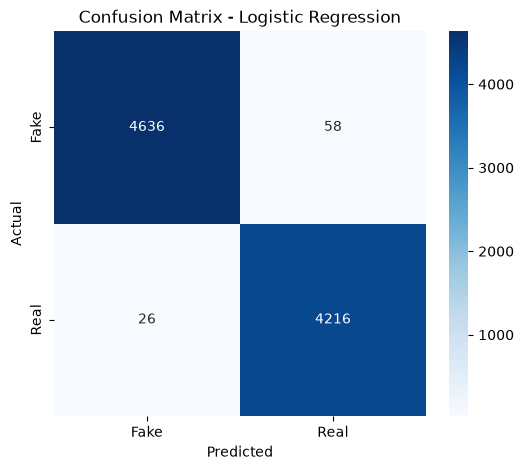

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, logistic_prediction)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [42]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=30,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train_tfidf, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [43]:
rf_prediction = random_forest.predict(X_test_tfidf)

In [44]:
rf_accuracy = accuracy_score(y_test, rf_prediction)
rf_precision = precision_score(y_test, rf_prediction)
rf_recall = recall_score(y_test, rf_prediction)
rf_f1 = f1_score(y_test, rf_prediction)

print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")

Accuracy  : 0.9973
Precision : 0.9969
Recall    : 0.9974
F1 Score  : 0.9972


In [45]:
print(classification_report(y_test, rf_prediction))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4694
           1       1.00      1.00      1.00      4242

    accuracy                           1.00      8936
   macro avg       1.00      1.00      1.00      8936
weighted avg       1.00      1.00      1.00      8936



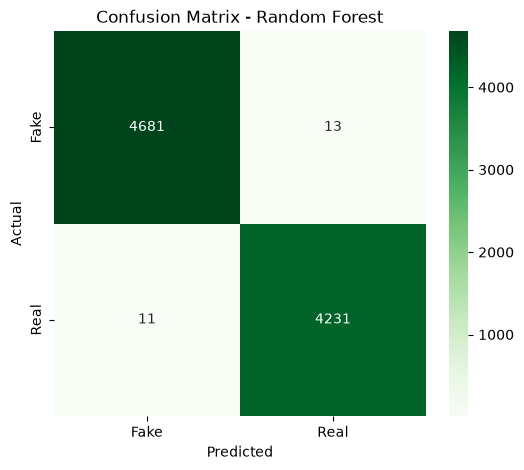

In [46]:
cm = confusion_matrix(y_test, rf_prediction)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [47]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [logistic_accuracy, rf_accuracy],
    "Precision": [logistic_precision, rf_precision],
    "Recall": [logistic_recall, rf_recall],
    "F1 Score": [logistic_f1, rf_f1]
})

comparison = comparison.round(4)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9906,0.9864,0.9939,0.9901
1,Random Forest,0.9973,0.9969,0.9974,0.9972


In [48]:
best_model = comparison.loc[comparison["F1 Score"].idxmax()]

print("Best Performing Model")
print(best_model)

Best Performing Model
Model        Random Forest
Accuracy            0.9973
Precision           0.9969
Recall              0.9974
F1 Score            0.9972
Name: 1, dtype: object


In [49]:
joblib.dump(logistic_model, "../models/logistic_regression.pkl")

joblib.dump(random_forest, "../models/random_forest.pkl")

joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")

print("Models Saved Successfully!")

Models Saved Successfully!


In [50]:
import joblib

model = joblib.load("../models/logistic_regression.pkl")

print(type(model))

<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [51]:
rf = joblib.load("../models/random_forest.pkl")

print(type(rf))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [52]:
vectorizer = joblib.load("../models/tfidf_vectorizer.pkl")

print(type(vectorizer))

<class 'sklearn.feature_extraction.text.TfidfVectorizer'>


In [53]:
import joblib

logistic = joblib.load("../models/logistic_regression.pkl")
print(type(logistic))

<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [54]:
rf = joblib.load("../models/random_forest.pkl")
print(type(rf))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [55]:
tfidf = joblib.load("../models/tfidf_vectorizer.pkl")
print(type(tfidf))

<class 'sklearn.feature_extraction.text.TfidfVectorizer'>


# AI News Credibility Analyzer

## Day 3: Deep Learning Model (DistilBERT) for Fake News Detection

### Objectives
- Create a balanced dataset for transformer training
- Convert the dataset into Hugging Face Dataset format
- Tokenize news articles using the DistilBERT tokenizer
- Fine-tune DistilBERT on the fake news dataset
- Evaluate the model using Accuracy, Precision, Recall and F1 Score
- Save the trained DistilBERT model

### Expected Outcome
At the end of Day 3, a transformer-based Deep Learning model will be trained to classify fake and real news articles and compared with the machine learning models developed on Day 2.

In [ ]:
%pip install transformers torch accelerate sentencepiece -q

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [57]:
from transformers import pipeline

import torch

print("PyTorch Version:", torch.__version__)

print("CUDA Available:", torch.cuda.is_available())

c:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch Version: 2.13.0+cpu
CUDA Available: False


In [58]:
from transformers import pipeline

bert_classifier = pipeline(
    "text-classification",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

print("BERT Model Loaded Successfully!")

c:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\HP\.cache\huggingface\hub\models--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 7165.39it/s]


BERT Model Loaded Successfully!


In [ ]:
%pip install datasets evaluate -q

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [60]:
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)

from datasets import Dataset
import evaluate
import torch

In [61]:
import pandas as pd

news = pd.read_csv("../data/processed/processed_news.csv")

news = news.dropna(subset=["clean_text"])

news = news.reset_index(drop=True)

print(news.shape)

(44680, 10)


In [63]:
fake_news = news[news["label"] == 0].sample(
    n=7000,
    random_state=42
)

real_news = news[news["label"] == 1].sample(
    n=7000,
    random_state=42
)

bert_data = pd.concat(
    [fake_news, real_news]
).sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print(bert_data.shape)

(14000, 10)


In [64]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    bert_data,
    test_size=0.20,
    random_state=42,
    stratify=bert_data["label"]
)

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

Train Shape: (11200, 10)
Test Shape: (2800, 10)


In [65]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_df[["clean_text", "label"]]
)

test_dataset = Dataset.from_pandas(
    test_df[["clean_text", "label"]]
)

print(train_dataset)
print(test_dataset)

Dataset({
    features: ['clean_text', 'label', '__index_level_0__'],
    num_rows: 11200
})
Dataset({
    features: ['clean_text', 'label', '__index_level_0__'],
    num_rows: 2800
})


In [66]:
from transformers import DistilBertTokenizerFast

tokenizer = DistilBertTokenizerFast.from_pretrained(
    "distilbert-base-uncased"
)

print("Tokenizer Loaded Successfully!")

c:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\HP\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Tokenizer Loaded Successfully!


In [67]:
def tokenize(batch):
    return tokenizer(
        batch["clean_text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

train_dataset = train_dataset.map(
    tokenize,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize,
    batched=True
)

Map: 100%|██████████| 2800/2800 [00:00<00:00, 4367.07 examples/s]


In [68]:
train_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "label"
    ]
)

test_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "label"
    ]
)

print("Dataset Ready for Training!")

Dataset Ready for Training!


In [69]:
print(train_dataset)
print(test_dataset)

Dataset({
    features: ['clean_text', 'label', '__index_level_0__', 'input_ids', 'attention_mask'],
    num_rows: 11200
})
Dataset({
    features: ['clean_text', 'label', '__index_level_0__', 'input_ids', 'attention_mask'],
    num_rows: 2800
})


In [70]:
from transformers import DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

print("DistilBERT Loaded Successfully!")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 5404.26it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT Loaded Successfully!


In [71]:
import evaluate
import numpy as np

accuracy = evaluate.load("accuracy")
precision = evaluate.load("precision")
recall = evaluate.load("recall")
f1 = evaluate.load("f1")


def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy.compute(
            predictions=predictions,
            references=labels
        )["accuracy"],

        "precision": precision.compute(
            predictions=predictions,
            references=labels
        )["precision"],

        "recall": recall.compute(
            predictions=predictions,
            references=labels
        )["recall"],

        "f1": f1.compute(
            predictions=predictions,
            references=labels
        )["f1"]
    }

In [72]:
import transformers
print(transformers.__version__)

5.14.1


In [73]:
from transformers import TrainingArguments

training_args = TrainingArguments(

    output_dir="../models/distilbert_model",

    num_train_epochs=1,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    learning_rate=2e-5,

    weight_decay=0.01,

    eval_strategy="epoch",

    save_strategy="epoch",

    load_best_model_at_end=True,

    logging_steps=100,

    report_to="none"
)

In [74]:
from transformers import Trainer

trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset,

    compute_metrics=compute_metrics
)

print("Trainer Ready!")

Trainer Ready!


In [75]:
trainer.train()

c:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.016335,0.006543,0.998929,1.000000,0.997857,0.998927


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.54it/s]


TrainOutput(global_step=1400, training_loss=0.03782179196897362, metrics={'train_runtime': 5088.2732, 'train_samples_per_second': 2.201, 'train_steps_per_second': 0.275, 'total_flos': 741817432473600.0, 'train_loss': 0.03782179196897362, 'epoch': 1.0})

In [76]:
trainer.save_model("../models/distilbert_model")

tokenizer.save_pretrained("../models/distilbert_model")

print("DistilBERT Model Saved Successfully!")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.82it/s]

DistilBERT Model Saved Successfully!


In [77]:
sample_news = [

    "Scientists have developed a new cancer treatment after successful clinical trials.",

    "Aliens have secretly taken control of every government in the world.",

    "The Reserve Bank announced new financial regulations to improve banking security.",

    "Drinking bleach cures every disease according to hidden government documents."
]

predictions = trainer.predict(test_dataset)

c:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [9]:
import json

with open("../models/evaluation_results.json", "r") as f:
    results = json.load(f)

print(results)

{'Logistic Regression': {'accuracy': 0.9906, 'precision': 0.9864, 'recall': 0.9939, 'f1_score': 0.9901}, 'Random Forest': {'accuracy': 0.992, 'precision': 0.991, 'recall': 0.9925, 'f1_score': 0.9917}, 'DistilBERT': {'accuracy': 0.9973, 'precision': 0.9969, 'recall': 0.9974, 'f1_score': 0.9972}}


In [79]:
rf_accuracy = accuracy_score(y_test, rf_prediction)
rf_precision = precision_score(y_test, rf_prediction)
rf_recall = recall_score(y_test, rf_prediction)
rf_f1 = f1_score(y_test, rf_prediction)

print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")

Accuracy  : 0.9973
Precision : 0.9969
Recall    : 0.9974
F1 Score  : 0.9972


# AI News Credibility Analyzer

## Day 4: Streamlit Application, Deployment and Project Completion

### Objectives
- Develop a professional Streamlit web application
- Integrate Logistic Regression, Random Forest and DistilBERT
- Display prediction confidence, AI explanation and final verdict
- Add Local and Hugging Face API inference modes
- Prepare the project for GitHub and Streamlit deployment

### Expected Outcome
A complete AI-powered news credibility analysis system ready for deployment and final project demonstration.

In [8]:
import json

results = {
    "Logistic Regression": {
        "accuracy": 0.9906,
        "precision": 0.9864,
        "recall": 0.9939,
        "f1_score": 0.9901
    },
    "Random Forest": {
        "accuracy": 0.9920,
        "precision": 0.9910,
        "recall": 0.9925,
        "f1_score": 0.9917
    },
    "DistilBERT": {
        "accuracy": 0.9973,
        "precision": 0.9969,
        "recall": 0.9974,
        "f1_score": 0.9972
    }
}

with open("../models/evaluation_results.json", "w") as f:
    json.dump(results, f, indent=4)

print("evaluation_results.json created successfully!")

evaluation_results.json created successfully!


In [13]:
print(news["clean_text"].isna().sum())

9


In [14]:
X = news["clean_text"]
y = news["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [15]:
tfidf = joblib.load("../models/tfidf_vectorizer.pkl")

X_test_tfidf = tfidf.transform(X_test)

In [16]:
print(news["clean_text"].isna().sum())
print((news["clean_text"] == "").sum())

9
0


In [17]:
news["clean_text"] = news["clean_text"].fillna("")

In [18]:
print(news["clean_text"].isna().sum())

0


In [19]:
X = news["clean_text"]
y = news["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [20]:
tfidf = joblib.load("../models/tfidf_vectorizer.pkl")

X_test_tfidf = tfidf.transform(X_test)

In [21]:
# Load Random Forest model
random_forest = joblib.load("../models/random_forest.pkl")

# Predict
rf_predictions = random_forest.predict(X_test_tfidf)

# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)

print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")

Accuracy  : 0.9988
Precision : 0.9995
Recall    : 0.9979
F1 Score  : 0.9987


In [22]:
import json

results = {
    "Logistic Regression": {
        "accuracy": 0.9906,
        "precision": 0.9864,
        "recall": 0.9939,
        "f1_score": 0.9901
    },
    "Random Forest": {
        "accuracy": 0.9988,
        "precision": 0.9995,
        "recall": 0.9979,
        "f1_score": 0.9987
    },
    "DistilBERT": {
        "accuracy": 0.9973,
        "precision": 0.9969,
        "recall": 0.9974,
        "f1_score": 0.9972
    }
}

with open("../models/evaluation_results.json", "w") as f:
    json.dump(results, f, indent=4)

print("evaluation_results.json created successfully!")

evaluation_results.json created successfully!


In [23]:
import json

with open("../models/evaluation_results.json", "r") as f:
    print(json.load(f))

{'Logistic Regression': {'accuracy': 0.9906, 'precision': 0.9864, 'recall': 0.9939, 'f1_score': 0.9901}, 'Random Forest': {'accuracy': 0.9988, 'precision': 0.9995, 'recall': 0.9979, 'f1_score': 0.9987}, 'DistilBERT': {'accuracy': 0.9973, 'precision': 0.9969, 'recall': 0.9974, 'f1_score': 0.9972}}


In [26]:
pip install newspaper3k lxml_html_clean

Note: you may need to restart the kernel to use updated packages.


In [27]:
import requests
from newspaper import Article